In [8]:
import pandas as pd 
df = pd.read_csv('Admission_Predict.csv')
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [9]:
df.isna().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [10]:
df = df.drop('Serial No.', axis=1)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

In [17]:
x = df.drop("Chance of Admit", axis=1)  
y = df["Chance of Admit"]

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(max_depth=4,)
model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=4)

In [46]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.005368133683445525
R2 Score: 0.7921210170415511


In [47]:
print("Train R2:", model.score(x_train, y_train))
print("Test R2:", model.score(x_test, y_test))

Train R2: 0.8118761904663878
Test R2: 0.7921210170415511


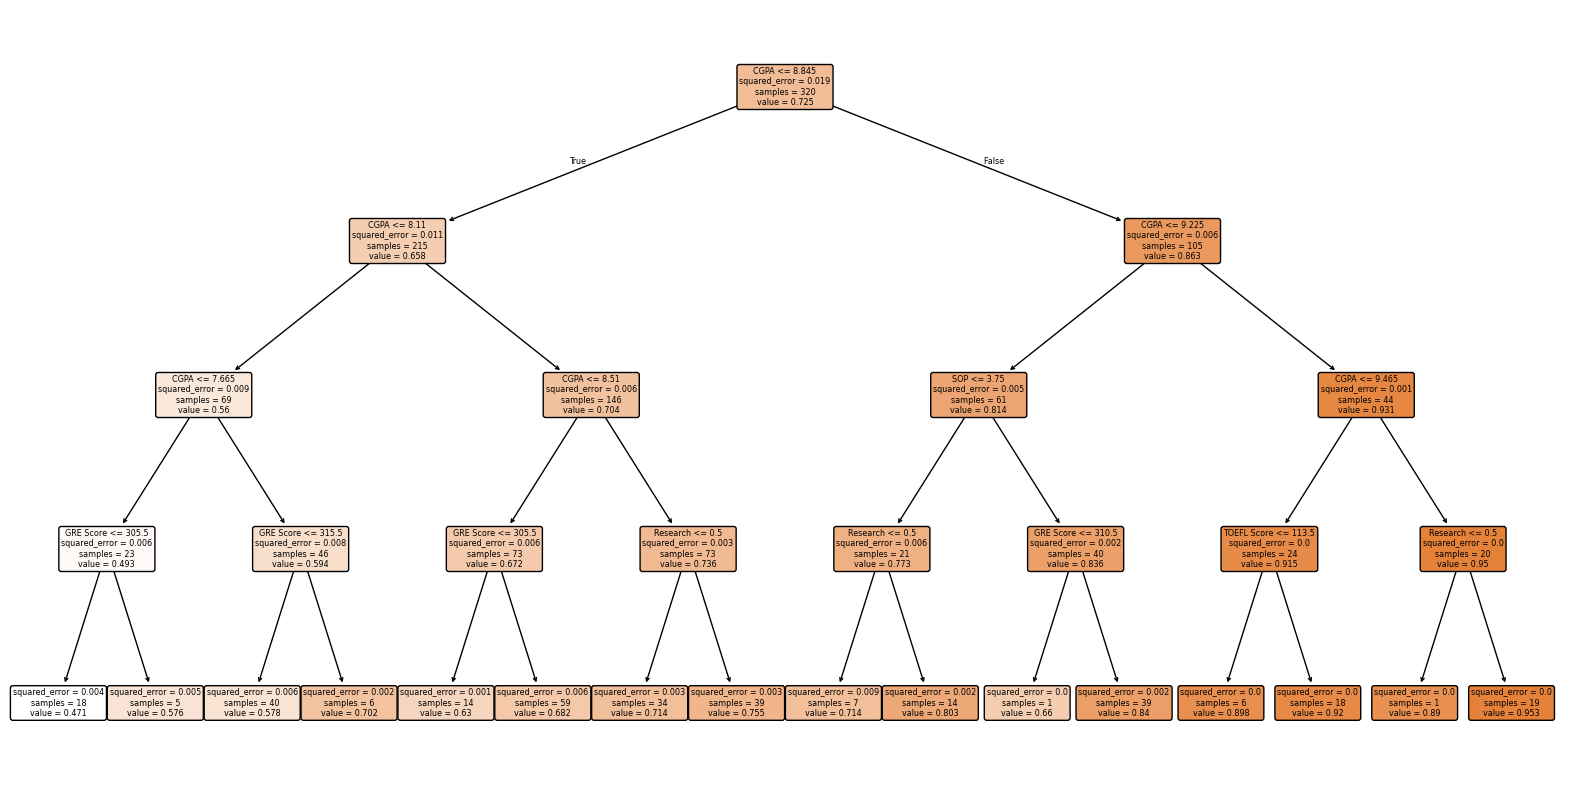

In [48]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=x.columns,
    filled=True,
    rounded=True,
)
plt.show()